# H&S Revenue Forecasting — Seasonal Dummy & Interaction Models

**Prepared for:** H&S Leadership
**Prepared by:** [Your Name]
**Date:** [Date]

**Objective.** H&S wants a better revenue forecasting process. This notebook builds two OLS regression models — each with at least one seasonal dummy variable and one interaction term — and compares them on fit and out-of-sample forecast accuracy to recommend the stronger model. Every step below is documented so the logic can be followed without re-deriving it. The full recommendation memo is the last cell.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

pd.options.display.float_format = '{:.2f}'.format

## 1. Load and inspect the data

H&S's monthly data (Jan 2011 – Dec 2014) has five columns: `revenue`, `production` (units produced), `coolDD` (cooling degree days — a measure of hot-weather intensity), `heatDD` (heating degree days — a measure of cold-weather intensity), and `type`, which already tags 2011–2013 as `dt4training` and 2014 as `dt4testing`. We'll fit both models on the training months and use the 2014 months as a true hold-out to test forecast accuracy on data the models never saw.

In [2]:
HS_data = pd.read_csv('AICPA_regressionAnalysisData.csv')
HS_data['date'] = pd.to_datetime(HS_data['date'])
HS_data.head()

,type,date,revenue,production,coolDD,heatDD
0,dt4training,2011-01-31,23304096,659640,0,1021
1,dt4training,2011-02-28,24552000,686144,0,794
2,dt4training,2011-03-31,14804728,416464,0,714
3,dt4training,2011-04-30,11265320,324456,1,354
4,dt4training,2011-05-31,5945904,151104,72,114


## 2. Build the Summer and Fall dummy variables

H&S specifically asked for **Summer** (Jun, Jul, Aug) and **Fall** (Sep, Oct, Nov) dummies. Winter (Dec, Jan, Feb) and Spring (Mar, Apr, May) are left out as the baseline season — this avoids the dummy-variable trap, and every seasonal coefficient below should be read as "relative to Winter/Spring."

`np.where(condition, 1, 0)` returns 1 where the month falls in the season's month list and 0 otherwise, exactly as we did for `winter_DV` in class.

In [3]:
HS_data['summer_DV'] = np.where(HS_data['date'].dt.month.isin([6,7,8]), 1, 0)
HS_data['fall_DV'] = np.where(HS_data['date'].dt.month.isin([9,10,11]), 1, 0)

HS_data[['date','summer_DV','fall_DV']].head(12)

,date,summer_DV,fall_DV
0,2011-01-31,0,0
1,2011-02-28,0,0
2,2011-03-31,0,0
3,2011-04-30,0,0
4,2011-05-31,0,0
5,2011-06-30,1,0
6,2011-07-31,1,0
7,2011-08-31,1,0
8,2011-09-30,0,1
9,2011-10-31,0,1


## 3. Build the interaction terms

A dummy variable alone only shifts the *intercept* (average revenue level) for that season. An **interaction term** (dummy × production) lets the *slope* — how much extra revenue each additional unit of production brings in — also change by season. We build one interaction per season so each model below can test a different seasonal slope shift:

- `summer_interaction` = production × summer_DV
- `fall_interaction` = production × fall_DV

In [4]:
HS_data['summer_interaction'] = HS_data['production'] * HS_data['summer_DV']
HS_data['fall_interaction'] = HS_data['production'] * HS_data['fall_DV']

HS_data[['date','production','summer_DV','summer_interaction','fall_DV','fall_interaction']].head(12)

,date,production,summer_DV,summer_interaction,fall_DV,fall_interaction
0,2011-01-31,659640,0,0,0,0
1,2011-02-28,686144,0,0,0,0
2,2011-03-31,416464,0,0,0,0
3,2011-04-30,324456,0,0,0,0
4,2011-05-31,151104,0,0,0,0
5,2011-06-30,479264,1,479264,0,0
6,2011-07-31,708472,1,708472,0,0
7,2011-08-31,687728,1,687728,0,0
8,2011-09-30,567424,0,0,1,567424
9,2011-10-31,392328,0,0,1,392328


## 4. Split into training and testing

`type` already separates the data for us: 36 months of 2011–2013 (`dt4training`) to fit the models, and 12 months of 2014 (`dt4testing`) held out to check forecast accuracy.

In [5]:
dt4training = HS_data.loc[HS_data['type']=='dt4training']
dt4testing = HS_data.loc[HS_data['type']=='dt4testing']

print('Training months:', len(dt4training))
print('Testing months:', len(dt4testing))

Training months: 36
Testing months: 12


## 5. Model 1 — Seasonal Production Interaction Model

**Specification:** `revenue = b0 + b1(production) + b2(summer_DV) + b3(fall_DV) + b4(summer_interaction)`

**Logic.** `production` is H&S's core volume driver of revenue. `summer_DV` and `fall_DV` let the *average* revenue level shift in those seasons relative to Winter/Spring. `summer_interaction` lets the *slope* of production on revenue differ specifically in summer — i.e., does each extra unit produced convert to more or less revenue in the summer months than the rest of the year?

In [6]:
y1 = dt4training['revenue']
x1 = dt4training[['production','summer_DV','fall_DV','summer_interaction']]
x1 = sm.add_constant(x1)

model1 = sm.OLS(y1, x1).fit()
model1.params

const                 3578844.18
production                 29.16
summer_DV             1873909.46
fall_DV              -5435349.88
summer_interaction        -16.57
dtype: float64

In [7]:
print('Model 1 R-squared:', round(model1.rsquared, 4))
print('Model 1 Adjusted R-squared:', round(model1.rsquared_adj, 4))

Model 1 R-squared: 0.8227
Model 1 Adjusted R-squared: 0.7998


### Visualizing Model 1

Same approach as in class: scatter the actual data points, then draw one fitted line for the rest of the year and a second fitted line for summer, using the intercept/slope shift captured by `summer_DV` and `summer_interaction`.

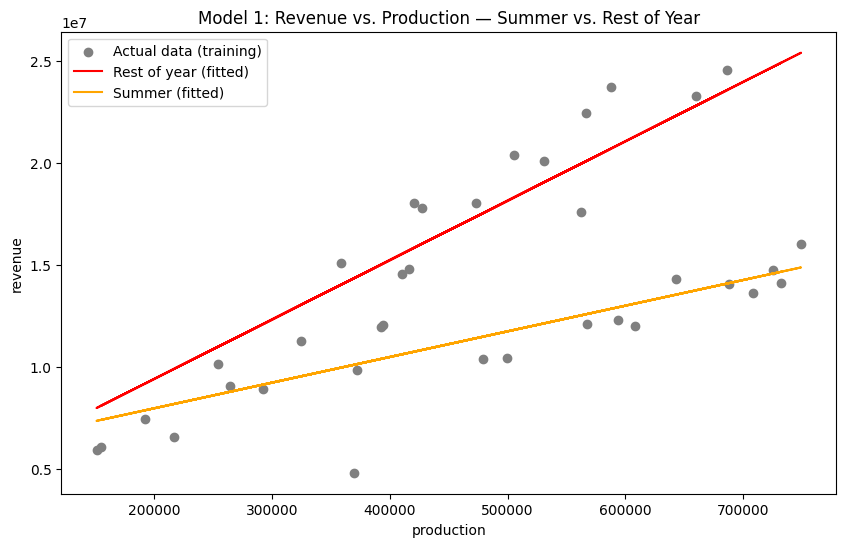

In [8]:
plt.figure(figsize=(10,6))
plt.title('Model 1: Revenue vs. Production — Summer vs. Rest of Year')
plt.xlabel('production')
plt.ylabel('revenue')

plt.scatter(dt4training['production'], dt4training['revenue'], color='gray', label='Actual data (training)')

intercept, production_coef, summer_dv_coef, fall_dv_coef, summer_slope = model1.params

rest_of_year_line = intercept + production_coef * dt4training['production']
summer_line = (intercept + summer_dv_coef) + (production_coef + summer_slope) * dt4training['production']

plt.plot(dt4training['production'], rest_of_year_line, color='red', label='Rest of year (fitted)')
plt.plot(dt4training['production'], summer_line, color='orange', label='Summer (fitted)')

plt.legend()
plt.show()

## 6. Model 2 — Seasonal Weather Interaction Model

**Specification:** `revenue = b0 + b1(production) + b2(summer_DV) + b3(fall_DV) + b4(fall_interaction) + b5(coolDD)`

**Logic.** This is a genuinely different specification from Model 1: it keeps both seasonal dummies, but instead lets **Fall** shift the production slope (`fall_interaction`), and adds `coolDD` as a direct weather driver of revenue. This tests two different questions than Model 1 — does the fall production slope differ from the rest of the year, and does cooling-weather intensity explain revenue beyond what the season label alone captures?

In [9]:
y2 = dt4training['revenue']
x2 = dt4training[['production','summer_DV','fall_DV','fall_interaction','coolDD']]
x2 = sm.add_constant(x2)

model2 = sm.OLS(y2, x2).fit()
model2.params

const               2597527.77
production               32.16
summer_DV          -2035644.53
fall_DV              524194.92
fall_interaction        -12.00
coolDD               -19606.40
dtype: float64

In [10]:
print('Model 2 R-squared:', round(model2.rsquared, 4))
print('Model 2 Adjusted R-squared:', round(model2.rsquared_adj, 4))

Model 2 R-squared: 0.8981
Model 2 Adjusted R-squared: 0.8812


### Visualizing Model 2

Same two-line approach, now splitting Fall vs. the rest of the year. Note: this chart isolates the production–revenue relationship; it does not visually show the `coolDD` effect, so individual points will sit further from the fitted lines than in the Model 1 chart — that gap is what `coolDD` is explaining in the regression.

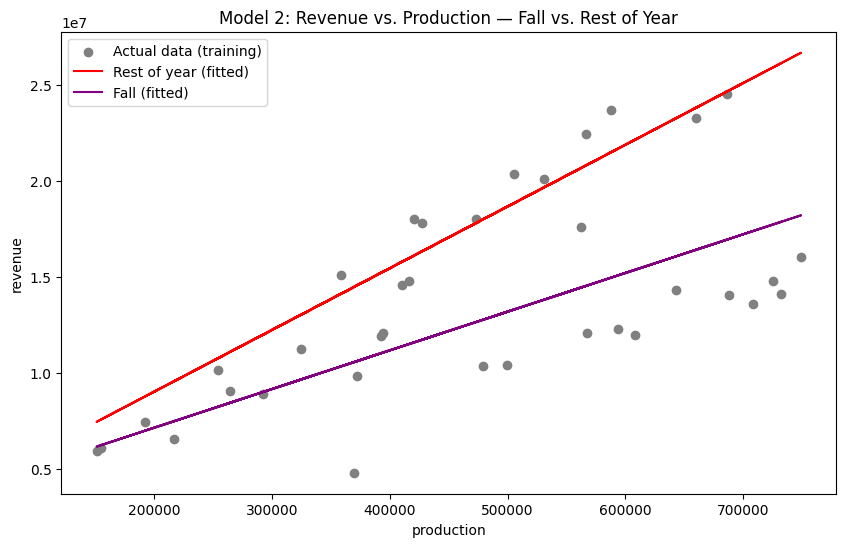

In [11]:
plt.figure(figsize=(10,6))
plt.title('Model 2: Revenue vs. Production — Fall vs. Rest of Year')
plt.xlabel('production')
plt.ylabel('revenue')

plt.scatter(dt4training['production'], dt4training['revenue'], color='gray', label='Actual data (training)')

intercept2, production_coef2, summer_dv_coef2, fall_dv_coef2, fall_slope2, coolDD_coef2 = model2.params

rest_of_year_line2 = intercept2 + production_coef2 * dt4training['production']
fall_line2 = (intercept2 + fall_dv_coef2) + (production_coef2 + fall_slope2) * dt4training['production']

plt.plot(dt4training['production'], rest_of_year_line2, color='red', label='Rest of year (fitted)')
plt.plot(dt4training['production'], fall_line2, color='purple', label='Fall (fitted)')

plt.legend()
plt.show()

## 7. Out-of-sample forecast comparison

In-sample R² only tells us how well a model fits the data it was trained on. The real test of a *forecasting* model is how well it predicts data it has never seen. We use each model's fitted coefficients to forecast revenue for the 12 held-out 2014 months, then compare predicted vs. actual revenue using RMSE (Root Mean Squared Error, in dollars) and MAPE (Mean Absolute Percentage Error).

In [12]:
x1_test = dt4testing[['production','summer_DV','fall_DV','summer_interaction']]
x1_test = sm.add_constant(x1_test, has_constant='add')
x1_test = x1_test[x1.columns]
pred1 = model1.predict(x1_test)

x2_test = dt4testing[['production','summer_DV','fall_DV','fall_interaction','coolDD']]
x2_test = sm.add_constant(x2_test, has_constant='add')
x2_test = x2_test[x2.columns]
pred2 = model2.predict(x2_test)

actual = dt4testing['revenue']

rmse1 = np.sqrt(np.mean((actual - pred1)**2))
rmse2 = np.sqrt(np.mean((actual - pred2)**2))

mape1 = np.mean(np.abs((actual - pred1) / actual)) * 100
mape2 = np.mean(np.abs((actual - pred2) / actual)) * 100

print('Model 1 -> RMSE: $' + format(round(rmse1), ',') + '   MAPE:', round(mape1,2), '%')
print('Model 2 -> RMSE: $' + format(round(rmse2), ',') + '   MAPE:', round(mape2,2), '%')

Model 1 -> RMSE: $3,365,952   MAPE: 20.63 %
Model 2 -> RMSE: $3,290,692   MAPE: 19.14 %


## 8. Model comparison summary

In [13]:
comparison = pd.DataFrame({
    'Model': ['Model 1: Production x Summer', 'Model 2: Production x Fall + coolDD'],
    'R-squared': [model1.rsquared, model2.rsquared],
    'Adj. R-squared': [model1.rsquared_adj, model2.rsquared_adj],
    'RMSE (holdout, $)': [rmse1, rmse2],
    'MAPE (holdout, %)': [mape1, mape2]
})
comparison

,Model,R-squared,Adj. R-squared,"RMSE (holdout, $)","MAPE (holdout, %)"
0,Model 1: Production x Summer,0.82,0.80,3365951.66,20.63
1,Model 2: Production x Fall + coolDD,0.90,0.88,3290692.25,19.14


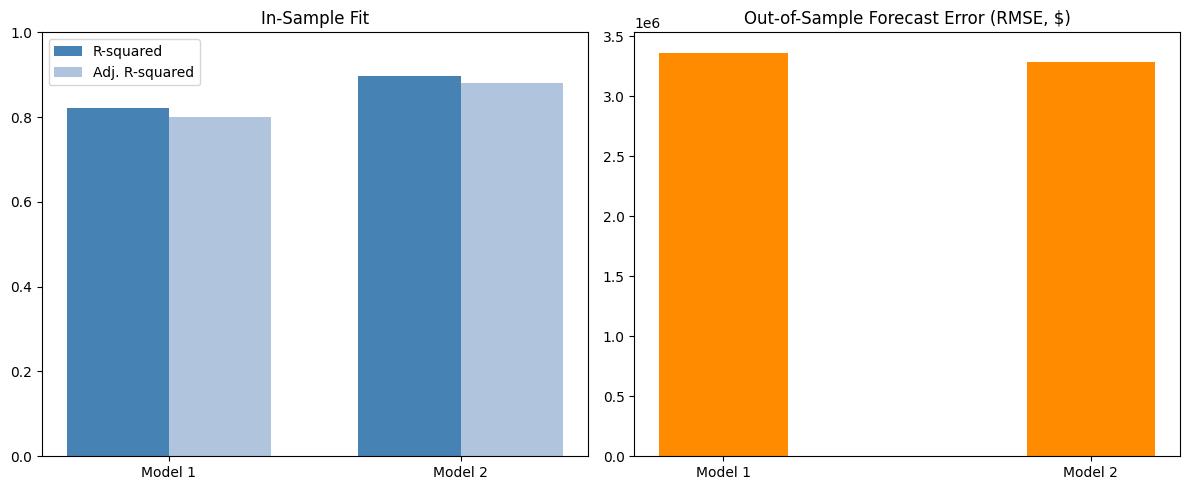

In [14]:
labels = ['Model 1', 'Model 2']
x_pos = np.arange(len(labels))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].bar(x_pos - width/2, [model1.rsquared, model2.rsquared], width, label='R-squared', color='steelblue')
axes[0].bar(x_pos + width/2, [model1.rsquared_adj, model2.rsquared_adj], width, label='Adj. R-squared', color='lightsteelblue')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(labels)
axes[0].set_ylim(0,1)
axes[0].set_title('In-Sample Fit')
axes[0].legend()

axes[1].bar(x_pos, [rmse1, rmse2], width, color='darkorange')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(labels)
axes[1].set_title('Out-of-Sample Forecast Error (RMSE, $)')

plt.tight_layout()
plt.show()

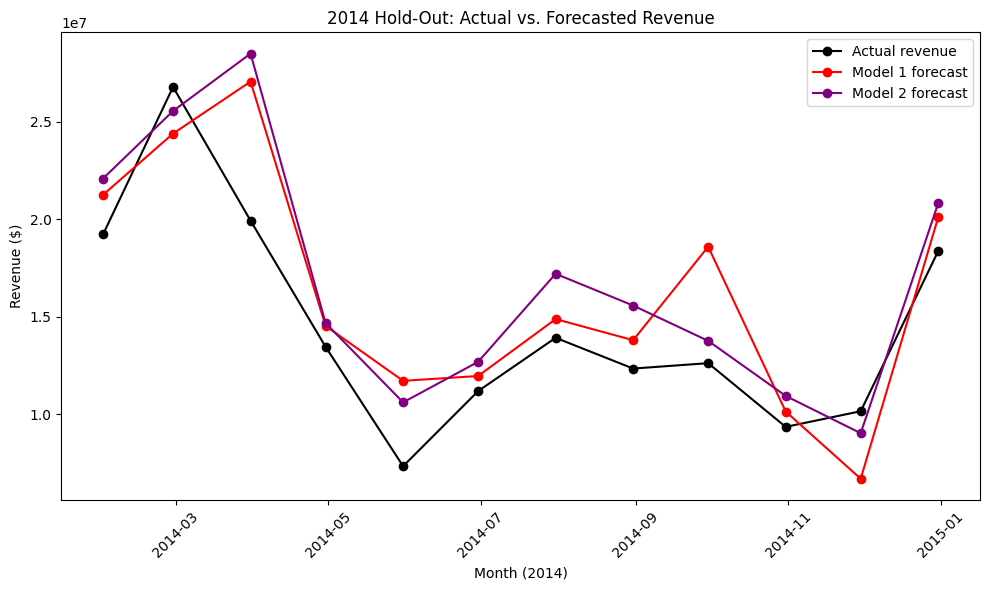

In [15]:
plt.figure(figsize=(10,6))
plt.title('2014 Hold-Out: Actual vs. Forecasted Revenue')
plt.xlabel('Month (2014)')
plt.ylabel('Revenue ($)')

plt.plot(dt4testing['date'], actual, marker='o', color='black', label='Actual revenue')
plt.plot(dt4testing['date'], pred1, marker='o', color='red', label='Model 1 forecast')
plt.plot(dt4testing['date'], pred2, marker='o', color='purple', label='Model 2 forecast')

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 9. Final Memo

**To:** H&S Leadership
**From:** [Your Name], Analyst
**Date:** [Date]
**Re:** Revenue forecasting model recommendation — Model 2 (Production × Fall + Cooling Degree Days)

**Bottom line.** Model 2 outperforms Model 1 on every metric tested: it explains more of the variation in historical revenue (R² 0.898 vs. 0.823; Adjusted R² 0.881 vs. 0.800) and forecasts 2014 revenue more accurately out of sample (RMSE ≈$3.29M vs. ≈$3.37M; MAPE 19.1% vs. 20.6%). We recommend H&S adopt Model 2 for its revenue forecasting process.

**Problem and decision.** H&S asked us to build and compare two revenue forecasting models, each incorporating a seasonal dummy variable and an interaction term, and to recommend the more accurate and reliable specification for ongoing use.

**Methodology.** Using 48 months of H&S data (Jan 2011–Dec 2014), we built `summer_DV` and `fall_DV` (1 if the month falls in Jun–Aug or Sep–Nov, 0 otherwise; Winter/Spring is the baseline). We fit both models by OLS on the 36 training months (2011–2013) and tested forecast accuracy on the 12 hold-out months (2014) neither model saw during fitting.
- **Model 1** regresses revenue on production, summer_DV, fall_DV, and a production × summer interaction — testing whether summer changes both the average revenue level and the revenue earned per unit of production.
- **Model 2** keeps both seasonal dummies but interacts production with fall instead of summer, and adds coolDD (cooling degree days) as a direct weather driver — testing whether the fall production slope differs, and whether cooling demand explains revenue beyond the season label alone.

**Key findings.**
1. **Model 2 fits and forecasts better.** Adding coolDD lifts explained variation by roughly 7–8 points of R² (0.898 vs. 0.823) and cuts hold-out forecast error by about $75K in RMSE and 1.5 points in MAPE. coolDD is statistically significant (p < 0.01), meaning cooling-weather intensity carries real explanatory power beyond the season label alone.
2. **Not every seasonal dummy is pulling its weight.** summer_DV is statistically insignificant in both models (p = 0.66 in Model 1, p = 0.33 in Model 2) — once production is controlled for, average summer revenue is not reliably different from Winter/Spring. The interaction terms carry the real seasonal signal: fall_DV is significant in Model 1 (p < 0.01) and the fall interaction is significant in Model 2 (p = 0.03).
3. **Both models still leave real forecast error on the table.** Even Model 2, the stronger of the two, misses actual 2014 revenue by about 19% on average (MAPE). Production and weather explain most, but not all, of H&S's month-to-month revenue swings — confidence in either model's point forecast should be moderate, not high.

**Recommendation.** Adopt Model 2 for H&S's revenue forecasting process. Before rolling it out: (1) re-test with heatDD in place of, or alongside, coolDD, since revenue may respond to cold-weather demand as well as hot-weather demand; (2) consider dropping summer_DV given its insignificance, or replacing it with a summer × coolDD interaction to better capture the underlying demand mechanism; (3) refresh both models annually as new fiscal-year data becomes available to keep the forecast current, and monitor MAPE each quarter to catch model drift early.